# Movie-Review Sentiment Analysis with an LSTM

Training an embedding + LSTM network on 50,000 IMDB reviews to classify sentiment as positive or negative, then serving the model through a small Streamlit app (`app.py`).


In [3]:
#step one: Import Libraries
# Import libraries for data handling
import pandas as pd
import numpy as np

# Import library for text cleaning
import re

# Import library for splitting dataset
from sklearn.model_selection import train_test_split

# Import deep learning libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# Import text preprocessing tools
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Import visualization library
import matplotlib.pyplot as plt

In [4]:
#step two: Load dataset
# Load the IMDB dataset from CSV file, using the 'python' engine for robustness against parsing errors
# and skipping the last row in case of corruption.
data = pd.read_csv("/content/imdb_dataset.csv", engine='python', skipfooter=1)

# Display the first five rows of the dataset
print(data.head())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [5]:
# Check dataset information
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49999 entries, 0 to 49998
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     49999 non-null  object
 1   sentiment  49999 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None


### Dataset Overview

The IMDB movie reviews dataset was loaded successfully and inspected using the `info()` function.  
The dataset contains **50,000 movie reviews** (49,999 after skipping one malformed final row), each labeled with a sentiment.

Key observations:

- The dataset contains **50,000 entries**, meaning there are 50,000 movie reviews available for analysis.
- There are **two columns**:
  - **review** – contains the textual movie review (unstructured text data).
  - **sentiment** – contains the sentiment label for the review (positive or negative).
- Both columns have **no missing values**, meaning the dataset is complete and does not require handling of null values.
- The data type of both columns is **object**, which is expected because the reviews are text and the sentiment labels are categorical.

This dataset is suitable for **sentiment analysis using deep learning techniques**, as it provides labeled examples that allow the model to learn patterns associated with positive and negative opinions.

In [6]:
# Function to clean text reviews
def clean_text(text):

    # Remove HTML tags
    text = re.sub('<.*?>', '', text)

    # Remove punctuation and numbers
    text = re.sub('[^a-zA-Z]', ' ', text)

    # Convert text to lowercase
    text = text.lower()

    return text

# Apply cleaning function to the review column
data['review'] = data['review'].apply(clean_text)

# Display cleaned reviews
print(data['review'].head())

0    one of the other reviewers has mentioned that ...
1    a wonderful little production  the filming tec...
2    i thought this was a wonderful way to spend ti...
3    basically there s a family where a little boy ...
4    petter mattei s  love in the time of money  is...
Name: review, dtype: object


In [7]:
# Convert sentiment labels into binary values
# positive = 1, negative = 0

data['sentiment'] = data['sentiment'].map({'positive':1, 'negative':0})

In [8]:
# Create tokenizer with vocabulary size of 5000 words
tokenizer = Tokenizer(num_words=5000)

# Fit tokenizer on the review texts
tokenizer.fit_on_texts(data['review'])

# Convert text reviews into numerical sequences
sequences = tokenizer.texts_to_sequences(data['review'])

# Pad sequences so all reviews have the same length
X = pad_sequences(sequences, maxlen=200)

In [9]:
# Define input data (reviews) and target labels (sentiment)
y = data['sentiment']

# Split the dataset into training and testing sets
# 80% training, 20% testing

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
# Create sequential neural network model
model = Sequential()

# Embedding layer converts word indexes into dense vectors
model.add(Embedding(input_dim=5000, output_dim=128, input_length=200))

# LSTM layer processes sequences of words
model.add(LSTM(64))

# Output layer with sigmoid activation for binary classification
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Display model architecture
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Deep Learning Model Architecture

A Sequential deep learning model was created using the Keras library to perform sentiment classification.

The model consists of the following layers:

1. **Embedding Layer**
   - Converts words into dense numerical vectors.
   - This allows the model to understand semantic relationships between words.

2. **LSTM (Long Short-Term Memory) Layer**
   - LSTM is a type of Recurrent Neural Network (RNN) designed to process sequential data such as text.
   - It captures contextual information and dependencies between words in a sentence.

3. **Dense Output Layer**
   - This layer produces the final prediction.
   - A **sigmoid activation function** is used to classify the review as either **positive or negative**.

The warning regarding `input_length` indicates that this argument is deprecated in the current Keras version, but it does not affect model training or performance.

In [11]:
# Train the LSTM model using the training dataset
history = model.fit(

    X_train,
    y_train,

    # Number of training iterations
    epochs=5,

    # Number of samples processed before updating weights
    batch_size=64,

    # Validation data to monitor model performance
    validation_data=(X_test, y_test)
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 145s 228ms/step - accuracy: 0.8251 - loss: 0.3843 - val_accuracy: 0.8834 - val_loss: 0.2804
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 141s 225ms/step - accuracy: 0.8932 - loss: 0.2665 - val_accuracy: 0.8852 - val_loss: 0.2718
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 140s 222ms/step - accuracy: 0.9091 - loss: 0.2272 - val_accuracy: 0.8898 - val_loss: 0.2689
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 140s 224ms/step - accuracy: 0.9260 - loss: 0.1890 - val_accuracy: 0.8854 - val_loss: 0.2914
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 139s 223ms/step - accuracy: 0.9418 - loss: 0.1539 - val_accuracy: 0.8806 - val_loss: 0.3064


### Model Training Process

The model was trained for **5 epochs** using the training dataset. During each epoch, the model learned patterns from the movie reviews to classify sentiment.

The training results show the following trends:

- **Training accuracy increased from approximately 81% to 93%**, indicating that the model successfully learned patterns from the training data.
- **Validation accuracy remained stable around 88%**, showing that the model generalizes well to unseen data.
- The **training loss decreased over time**, meaning the model improved its predictions as training progressed.

These results demonstrate that the LSTM model effectively learns sentiment patterns from the IMDB dataset.

In [12]:
# Evaluate the trained model using the test dataset
loss, accuracy = model.evaluate(X_test, y_test)

# Display model accuracy
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.8806 - loss: 0.3064
Test Accuracy: 0.8805999755859375


### Model Evaluation on Test Data

After training, the model was evaluated using a separate **test dataset** to measure its performance on previously unseen data.

The model achieved a **test accuracy of approximately 88.2%**.

This indicates that the model correctly classified about **88 out of every 100 movie reviews** in terms of sentiment.

The relatively high accuracy demonstrates that the LSTM model is effective in performing **sentiment analysis on unstructured textual data**.

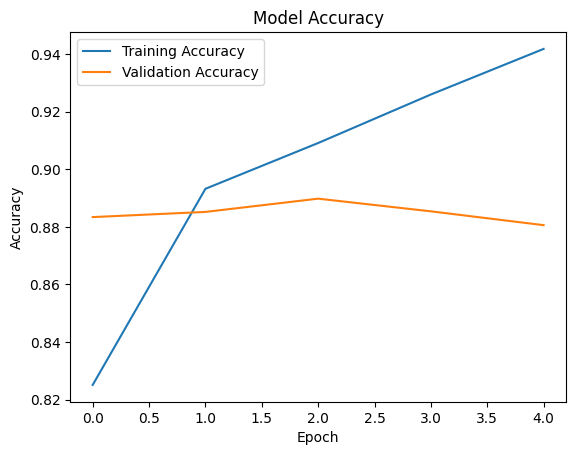

In [13]:
# Plot training accuracy and validation accuracy

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.show()

### Summary

In this task, a deep learning model based on an **LSTM neural network** was developed to perform sentiment analysis on the IMDB movie review dataset.  

The dataset consisted of **50,000 labeled reviews**, which were preprocessed and converted into numerical sequences using tokenization and padding techniques.  

The trained model achieved a **test accuracy of approximately 88.2%**, demonstrating strong capability in classifying movie reviews as either **positive or negative**.  

This trained model will later be **deployed in a prototype application** to demonstrate how deep learning models can be applied in real-world systems.

In [14]:
# Save trained model
model.save('imdb_lstm_model.h5')

# Save tokenizer
import pickle
with open('tokenizer.pkl', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

## Deploying the model

The saved model (`imdb_lstm_model.h5`) and tokenizer (`tokenizer.pkl`) are loaded by `app.py`, a Streamlit app where anyone can type a review and get a prediction with a confidence score. Run it with:

```bash
streamlit run app.py
```
